<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 60px 40px; border-radius: 12px; color: white; text-align: center;">
<h1 style="font-size: 2.4em; font-weight: 800; margin-bottom: 16px; letter-spacing: -0.5px;">LLM-for-LLM</h1>
<h2 style="font-size: 1.4em; font-weight: 400; color: #a0c4ff; margin-bottom: 32px;">Using Agentic AI to Optimize Critical Foundation Model Workloads</h2>
<hr style="border-color: rgba(255,255,255,0.2); margin: 24px 0;">
<p style="color: #ccc; font-size: 1.05em;">Platform: AMD ROCm &nbsp;&middot;&nbsp; Runtime: vLLM &nbsp;&middot;&nbsp; GPU: RDNA3 gfx1100</p>
<p style="color: #aaa; font-size: 0.95em; margin-top: 8px;">Model under optimization: <strong style="color:#7ec8e3;">Qwen3-8B</strong></p>
</div>

## Agenda

| # | Topic | Format |
|---|-------|--------|
| 1 | Why inference optimization matters — and why it's hard | Slides |
| 2 | The AMD ROCm + vLLM stack | Slides |
| 3 | Approach: agentic optimization with `vllm-optimize` | Slides |
| 4 | What the agent actually finds (Phase 2/3 analysis) | Live data |
| 5 | How TunableOps optimization works | Deep dive |
| 6 | End-to-end results on Qwen3-8B | Benchmark charts |
| **7** | **Live demo — agent optimizes a model in real time** | **OpenCode** |

---
## 1 · Why Inference Optimization Matters

### The deployment reality

```
Training cost:   $5M - $100M+  (one-time, amortized)
Inference cost:  pays per query, every day, forever
```

For a model serving **1M requests/day** at 1024 output tokens each:

| Throughput improvement | Daily GPU-hours saved | $/year saved (A100 at $3/hr) |
|------------------------|----------------------|------------------------------|
| +10% | ~2.4 GPU-hours | ~$2,600 |
| +50% | ~12 GPU-hours | ~$13,000 |
| **+58% (this workshop)** | **~14 GPU-hours** | **~$15,000** |

### Why it's hard

- **Kernel-level work** — profiling traces, GEMM shape analysis, hipBLASLt/rocBLAS tuning
- **Hardware-specific** — RDNA3 Wave32 != CDNA3 Wave64; different tile sizes, instruction sets
- **Runtime complexity** — vLLM's continuous batching creates variable batch sizes at runtime
- **No silver bullet** — the optimal kernel depends on (M, K, N, dtype, GPU arch, batch size)

> **The bottleneck:** a single ML engineer can optimize maybe 2-3 models per quarter.  
> With an agent, that becomes **2-3 models per hour**.

---
## 2 · The AMD ROCm + vLLM Stack

```
+----------------------------------------------------------+
|                    User / Application                    |
|              OpenAI-compatible REST API                  |
+----------------------------------------------------------+
|                        vLLM                              |
|  +---------------+  +--------------+  +-------------+   |
|  | PagedAttention|  |Cont. Batching|  | TP / PP     |   |
|  +---------------+  +--------------+  +-------------+   |
|  +----------------------------------------------------+  |
|  |  rocm_unquantized_gemm dispatch                    |  |
|  |  +-----------+  +----------+  +----------------+  |  |
|  |  | wvSplitK  |  |  LLMM1   |  | torch.linear   |  |  |
|  |  |  (n<=4)   |  |  (n=1)   |  | (n>4, Tunable) |  |  |
|  |  +-----------+  +----------+  +----------------+  |  |
|  +----------------------------------------------------+  |
+----------------------------------------------------------+
|          ROCm / HIP  .  hipBLASLt  .  rocBLAS            |
+----------------------------------------------------------+
|          AMD GPU  .  RDNA3 gfx1100  .  48 CUs            |
+----------------------------------------------------------+
```

**Key characteristics of RDNA3 (gfx1100) for inference:**
- Wave32 (not Wave64 like CDNA/MI300)
- WMMA instructions (not MFMA)
- 48 Compute Units, ~48 TFLOPS BF16
- 48 GB HBM2e
- TunableOps intercepts `aten::mm` -> offline rocBLAS kernel selection

---
## 3 · The Approach: `vllm-optimize` Skill

### What is it?

A **structured optimization skill** for Claude (via OpenCode) that guides an AI agent through a 6-phase vLLM optimization pipeline — from benchmarking raw throughput to deploying tuned kernels.

### The 6-Phase Pipeline

```
Phase 0 -- Environment       Detect GPU, verify ROCm, check vLLM version        ~10s
    |
Phase 1 -- Server Setup      Start vLLM with TunableOps recording + profiler    ~2min
    |
Phase 2 -- Bench + Profile   Throughput sweep (conc=1,4,16) + trace capture     ~15min
    |
Phase 3 -- Analysis          Kernel breakdown, GEMM shapes, optimization targets ~1min
    |
Phase 4 -- Kernel Optimize   TunableOps offline GEMM tuning (61 shapes)         ~5min
    |
Phase 5 -- Integration       Inject tuned kernels, E2E verification, rollback    ~8min
    |
Phase 6 -- Report            Verdict table, per-conc speedup, artifact summary   ~10s
```

**Total time: ~30 minutes** from raw model to optimized deployment.

### What makes it "agentic"?

- Agent reads profiler traces to find bottlenecks (not pre-programmed rules)
- Agent decides whether to proceed based on gate results
- Agent rolls back automatically on E2E regression
- Agent generates attribution when some scenarios don't improve (and explains why)
- **Demo mode**: pauses after each step for confirmation — you're always in control

---
## 4 · What the Agent Finds: Phase 3 Analysis

### GPU Kernel Breakdown — Qwen3-8B, conc=16, decode phase

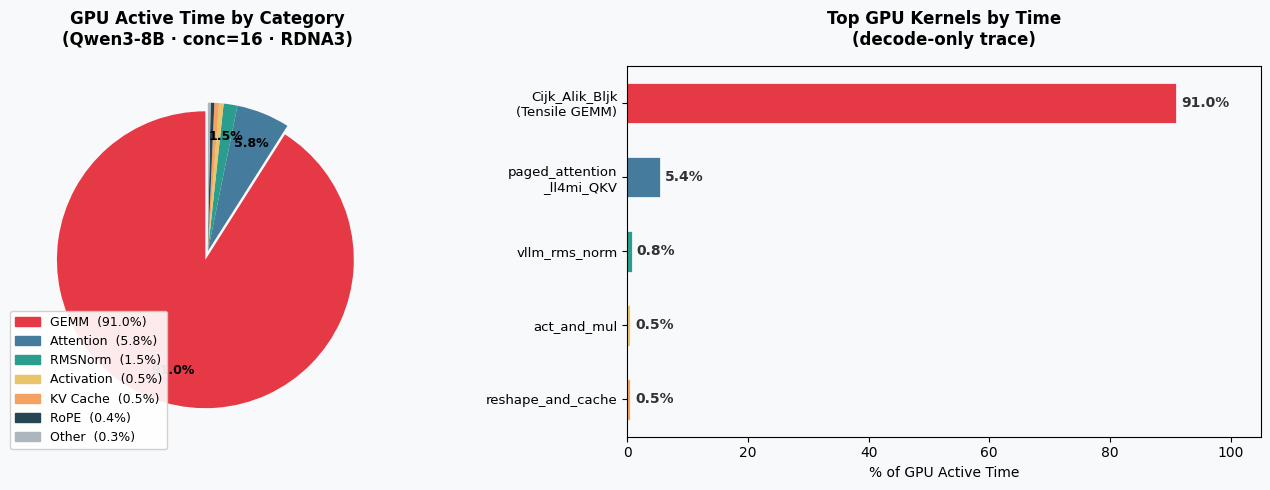


Conclusion: GEMM is 91% of GPU active time --> primary optimization target


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Phase 3 actual data -- Qwen3-8B, RDNA3 gfx1100, conc=16 decode-only trace
categories = ['GEMM', 'Attention', 'RMSNorm', 'Activation', 'KV Cache', 'RoPE', 'Other']
pct_active = [91.0,    5.8,         1.5,       0.5,          0.5,        0.4,    0.3]
colors     = ['#e63946','#457b9d', '#2a9d8f',  '#e9c46a',   '#f4a261', '#264653','#adb5bd']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f9fa')

# --- Pie chart: no per-wedge labels to avoid overlap; use legend instead ---
explode = [0.06 if c == 'GEMM' else 0 for c in categories]
wedges, _, autotexts = ax1.pie(
    pct_active, colors=colors, autopct='%1.1f%%',
    explode=explode, startangle=90, pctdistance=0.78,
    textprops={'fontsize': 9}
)
# Make the tiny slices' pct labels invisible to avoid clutter
for at, pct in zip(autotexts, pct_active):
    at.set_fontweight('bold')
    if pct < 1.0:
        at.set_visible(False)

# Legend replaces per-wedge labels
legend_patches = [mpatches.Patch(color=c, label=f'{cat}  ({pct:.1f}%)')
                  for c, cat, pct in zip(colors, categories, pct_active)]
ax1.legend(handles=legend_patches, loc='lower left', fontsize=9,
           framealpha=0.9, bbox_to_anchor=(-0.05, -0.05))
ax1.set_title('GPU Active Time by Category\n(Qwen3-8B · conc=16 · RDNA3)',
              fontsize=12, fontweight='bold', pad=15)
ax1.set_facecolor('#f8f9fa')

# --- Horizontal bar chart: top kernels ---
kernels = [
    'Cijk_Alik_Bljk\n(Tensile GEMM)',
    'paged_attention\n_ll4mi_QKV',
    'vllm_rms_norm',
    'act_and_mul',
    'reshape_and_cache',
]
kernel_pct    = [91.0, 5.4, 0.8, 0.5, 0.5]
kernel_colors = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#f4a261']

bars = ax2.barh(range(len(kernels)), kernel_pct, color=kernel_colors,
                edgecolor='white', linewidth=0.5, height=0.55)
ax2.set_yticks(range(len(kernels)))
ax2.set_yticklabels(kernels, fontsize=9.5)
ax2.set_xlabel('% of GPU Active Time', fontsize=10)
ax2.set_title('Top GPU Kernels by Time\n(decode-only trace)',
              fontsize=12, fontweight='bold', pad=15)
ax2.set_xlim(0, 105)
ax2.invert_yaxis()
ax2.set_facecolor('#f8f9fa')

for bar, pct in zip(bars, kernel_pct):
    ax2.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
             f'{pct:.1f}%', va='center', fontsize=10, fontweight='bold', color='#333')

plt.tight_layout()
plt.savefig('phase3_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nConclusion: GEMM is 91% of GPU active time --> primary optimization target')

### What the agent extracts: real GEMM shapes from profiler traces

```
Phase 3 Step 4 output (actual):

  Real GEMM shapes: 10 unique  M_values=[1, 16]  [OK]
  Top 5 by call count:
    M=16  K=4096   N=6144   calls=18432   <- QKV projection (conc=16 decode)
    M=16  K=4096   N=4096   calls=18432   <- Output projection
    M=16  K=4096   N=24576  calls=18432   <- Gate+Up (FFN)
    M=16  K=12288  N=4096   calls=18432   <- Down projection
    M=1   K=4096   N=6144   calls=4608    <- Same projections, conc=1 decode
```

**Key observation:** M = active decode batch size.  
Qwen3-8B has hidden_size=4096, intermediate_size=12288.  
The agent reads this from the raw HIP trace — no model config required.

---
## 5 · TunableOps: Offline GEMM Kernel Selection

### What is TunableOps?

PyTorch ROCm includes **TunableOps** — a mechanism to:
1. **Record** all `aten::mm` GEMM shapes seen at runtime -> saves to CSV
2. **Tune offline** — for each (M, K, N, dtype), benchmarks every available rocBLAS/hipBLASLt kernel
3. **Inject at serving time** — loads the winning kernel selection -> same computation, faster execution

```python
# Phase 1: enable recording
PYTORCH_TUNABLEOP_ENABLED=1
PYTORCH_TUNABLEOP_RECORD_UNTUNED=1
PYTORCH_TUNABLEOP_UNTUNED_FILENAME=untuned_shapes.csv

# Phase 4: tune offline (on a free GPU)
torch.cuda.tunable.tune_gemm_in_file(untuned_shapes.csv, tuned_gemm.csv)

# Phase 5: inject at serving time (via sitecustomize.py)
torch.cuda.tunable.read_file(tuned_gemm.csv)
```

### Phase 4 Results

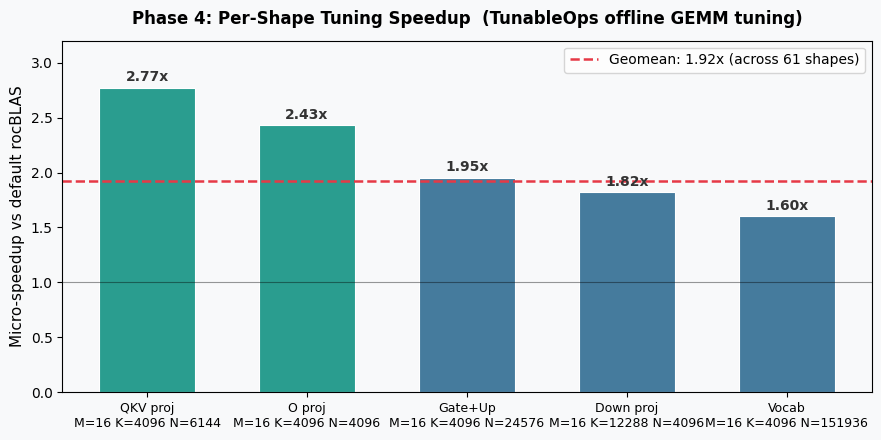


TunableOps micro-speedup: 1.919x geometric mean across 61 tuned shapes


In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor('#f8f9fa')

# Per-shape speedup for the 5 key M=16 decode shapes
shape_labels   = ['QKV proj\nM=16 K=4096 N=6144',
                  'O proj\nM=16 K=4096 N=4096',
                  'Gate+Up\nM=16 K=4096 N=24576',
                  'Down proj\nM=16 K=12288 N=4096',
                  'Vocab\nM=16 K=4096 N=151936']
shape_speedups = [2.77, 2.43, 1.95, 1.82, 1.60]

bar_colors = ['#2a9d8f' if s >= 2.0 else '#457b9d' if s >= 1.5 else '#adb5bd'
              for s in shape_speedups]
bars = ax.bar(range(len(shape_labels)), shape_speedups, color=bar_colors,
              edgecolor='white', linewidth=0.8, width=0.6)

ax.axhline(y=1.0,   color='black',   linestyle='-',  linewidth=0.8, alpha=0.4)
ax.axhline(y=1.919, color='#e63946', linestyle='--', linewidth=1.8,
           label='Geomean: 1.92x (across 61 shapes)')

ax.set_xticks(range(len(shape_labels)))
ax.set_xticklabels(shape_labels, fontsize=9)
ax.set_ylabel('Micro-speedup vs default rocBLAS', fontsize=11)
ax.set_title('Phase 4: Per-Shape Tuning Speedup  (TunableOps offline GEMM tuning)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylim(0, 3.2)
ax.legend(fontsize=10, loc='upper right')
ax.set_facecolor('#f8f9fa')

for bar, sp in zip(bars, shape_speedups):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.06,
            f'{sp:.2f}x', ha='center', fontsize=10, fontweight='bold', color='#333')

plt.tight_layout()
plt.savefig('phase4_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTunableOps micro-speedup: 1.919x geometric mean across 61 tuned shapes')

---
## 6 · End-to-End Results: Qwen3-8B on RDNA3

### Benchmark configuration
```
Model:   Qwen3-8B  (hidden=4096, layers=36, heads=32, intermediate=12288)
GPU:     AMD RDNA3 gfx1100  .  48 CUs  .  48 GB HBM
vLLM:    --enforce-eager  .  TP=1  .  max_model_len=4096
dtype:   bfloat16
ISL x OSL: 1024 x 1024 tokens
```

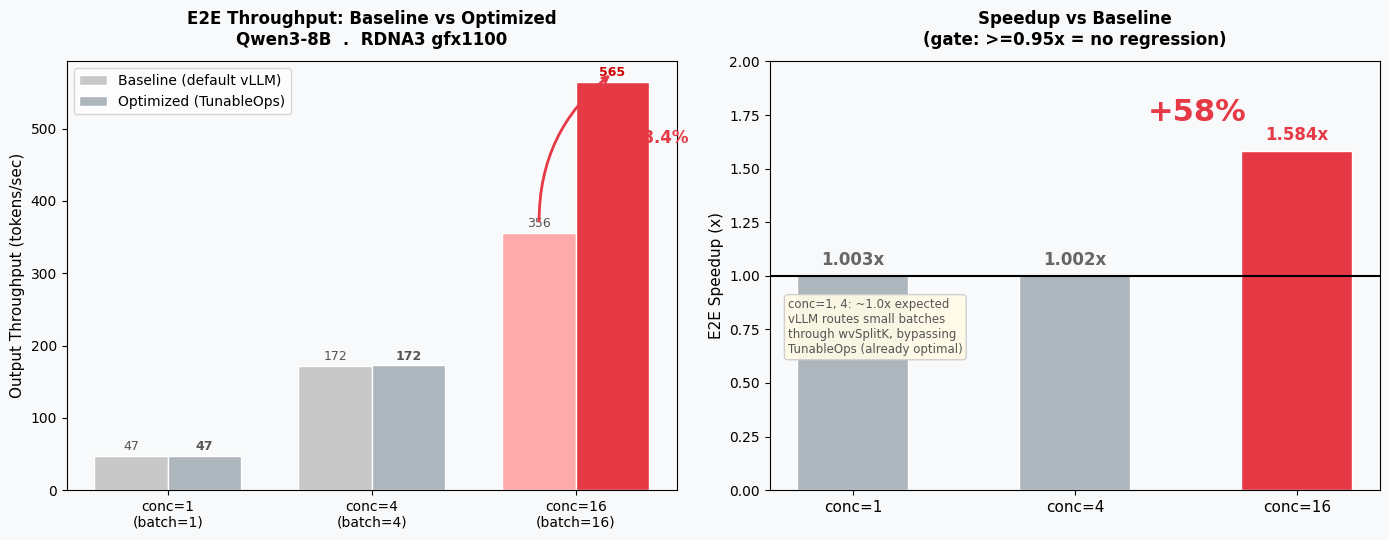


 RESULT SUMMARY
 conc=1  (single-user):  46.8 -> 46.9 TPS  (1.003x)
 conc=4  (light load):   172.0 -> 172.4 TPS  (1.002x)
 conc=16 (medium load):  356.3 -> 564.8 TPS  (1.584x)
 Integration: SUCCESSFUL  All gates PASSED  No rollback


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Actual Phase 5 integration results
concurrencies = [1,     4,     16   ]
baseline_tps  = [46.8,  172.0, 356.3]
patched_tps   = [46.9,  172.4, 564.8]
speedups      = [1.003, 1.002, 1.584]

x     = np.arange(len(concurrencies))
width = 0.36

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('#f8f9fa')

# ---- Left: grouped bar chart ----
bars1 = ax1.bar(x - width / 2, baseline_tps, width,
                label='Baseline (default vLLM)',
                color=['#c8c8c8', '#c8c8c8', '#ffaaaa'], edgecolor='white')
bars2 = ax1.bar(x + width / 2, patched_tps, width,
                label='Optimized (TunableOps)',
                color=['#adb5bd', '#adb5bd', '#e63946'], edgecolor='white')

ax1.set_xticks(x)
ax1.set_xticklabels([f'conc={c}\n(batch={c})' for c in concurrencies], fontsize=10)
ax1.set_ylabel('Output Throughput (tokens/sec)', fontsize=11)
ax1.set_title('E2E Throughput: Baseline vs Optimized\nQwen3-8B  .  RDNA3 gfx1100',
              fontsize=12, fontweight='bold', pad=12)
ax1.legend(fontsize=10, loc='upper left')
ax1.set_facecolor('#f8f9fa')

# Value labels -- placed above bars only for conc=16 to avoid clutter
for bar, tps in zip(bars1, baseline_tps):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
             f'{tps:.0f}', ha='center', va='bottom', fontsize=9, color='#555')
for bar, tps in zip(bars2, patched_tps):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
             f'{tps:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold',
             color='#c00' if tps > 500 else '#555')

# Arrow + label for conc=16 gain -- anchored clearly outside bars
ax1.annotate('', xy=(x[2] + width / 2, patched_tps[2] + 12),
             xytext=(x[2] - width / 2, baseline_tps[2] + 12),
             arrowprops=dict(arrowstyle='->', color='#e63946', lw=2.0,
                             connectionstyle='arc3,rad=-0.25'))
ax1.text(x[2] + 0.38, (patched_tps[2] + baseline_tps[2]) / 2 + 20,
         '+58.4%', fontsize=12, fontweight='bold', color='#e63946', ha='center')

# ---- Right: speedup bar ----
bars3 = ax2.bar(x, speedups, color=['#adb5bd', '#adb5bd', '#e63946'],
                edgecolor='white', width=0.5)
ax2.axhline(y=1.0, color='black', linestyle='-', linewidth=1.5)
ax2.set_xticks(x)
ax2.set_xticklabels([f'conc={c}' for c in concurrencies], fontsize=11)
ax2.set_ylabel('E2E Speedup (x)', fontsize=11)
ax2.set_title('Speedup vs Baseline\n(gate: >=0.95x = no regression)',
              fontsize=12, fontweight='bold', pad=12)
ax2.set_ylim(0, 2.0)
ax2.set_facecolor('#f8f9fa')

for bar, sp, conc in zip(bars3, speedups, concurrencies):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
             f'{sp:.3f}x', ha='center', va='bottom', fontsize=12, fontweight='bold',
             color='#e63946' if conc == 16 else '#666')

# Attribution note
ax2.text(0.03, 0.38,
         'conc=1, 4: ~1.0x expected\n'
         'vLLM routes small batches\n'
         'through wvSplitK, bypassing\n'
         'TunableOps (already optimal)',
         transform=ax2.transAxes, fontsize=8.5, color='#555', va='center',
         bbox=dict(boxstyle='round', facecolor='#fffbe6', edgecolor='#ccc', alpha=0.92))

ax2.text(0.62, 0.88, '+58%', transform=ax2.transAxes,
         fontsize=22, fontweight='bold', color='#e63946', va='center')

plt.tight_layout()
plt.savefig('e2e_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '=' * 55)
print(' RESULT SUMMARY')
print('=' * 55)
print(f' conc=1  (single-user):  {baseline_tps[0]:.1f} -> {patched_tps[0]:.1f} TPS  ({speedups[0]:.3f}x)')
print(f' conc=4  (light load):   {baseline_tps[1]:.1f} -> {patched_tps[1]:.1f} TPS  ({speedups[1]:.3f}x)')
print(f' conc=16 (medium load):  {baseline_tps[2]:.1f} -> {patched_tps[2]:.1f} TPS  ({speedups[2]:.3f}x)')
print('=' * 55)
print(' Integration: SUCCESSFUL  All gates PASSED  No rollback')

---
## 7 · Live Demo

<div style="background: linear-gradient(135deg, #1a1a2e, #16213e); padding: 32px; border-radius: 10px; color: white;">

<h3 style="color: #7ec8e3; margin-top: 0;">Hands-On: Agent Optimizes a Model in Real Time</h3>

<p style="color: #ccc;">We will now run the full 6-phase optimization pipeline on a live model using OpenCode.</p>

<h4 style="color: #a0c4ff;">Steps:</h4>

<ol style="color: #ddd; line-height: 2;">
<li>Open OpenCode in terminal: <code style="background:#0f3460; padding:2px 6px; border-radius:4px;">opencode</code></li>
<li>Invoke the skill: <code style="background:#0f3460; padding:2px 6px; border-radius:4px;">/vllm-optimize Qwen3-8B</code></li>
<li>Answer intake questions (demo mode: <strong>Yes</strong>)</li>
<li>Watch the agent profile, analyze, tune, and verify</li>
<li>Confirm each step as it completes</li>
</ol>

<hr style="border-color: rgba(255,255,255,0.15); margin: 20px 0;">

<h4 style="color: #a0c4ff;">What to watch for:</h4>
<ul style="color: #ccc; line-height: 1.8;">
<li>Phase 2: TunableOps captures GEMM shapes automatically</li>
<li>Phase 3: Agent reads profiler trace &rarr; finds GEMM = 91% GPU time</li>
<li>Phase 4: Offline tuning on a free GPU (no serving interruption)</li>
<li>Phase 5: Injection via <code>sitecustomize.py</code> + PYTHONPATH &mdash; no vLLM code changes</li>
<li>Phase 5: Attribution printed for conc=1,4 (~1.0x expected)</li>
<li>Phase 6: Final report with speedup verdict</li>
</ul>

</div>

### Expected timeline

```
Phase 0 env:         ~10s    GPU detection, ROCm version check
Phase 1 server:      ~2min   Start vLLM with profiler + TunableOps recording
Phase 2 bench:       ~12min  Benchmark sweep (conc=1,4,16) + 2 profiler traces
Phase 3 analysis:    ~1min   Kernel breakdown + shape extraction (parallel)
Phase 4 optimize:    ~5min   TunableOps tunes 61 shapes on free GPU
Phase 5 integrate:   ~8min   Restart patched server + E2E verification
Phase 6 report:      ~10s    Final markdown report
-----------------------------------------------------
Total:               ~30min  for Qwen3-8B on 1x RDNA3
```

---
## Summary

| | |
|--|--|
| **Model** | Qwen3-8B (8B parameters, BF16) |
| **GPU** | AMD RDNA3 gfx1100 &middot; 48 CUs &middot; 48 GB HBM |
| **Baseline -> Optimized** | 356 -> 565 TPS at conc=16 |
| **Speedup** | **+58.4%** throughput at medium load |
| **Method** | TunableOps offline rocBLAS kernel selection |
| **Shapes tuned** | 61 (M=7 to M=2048) |
| **Micro-speedup** | 1.92x geometric mean |
| **Time to optimize** | ~30 minutes, fully automated |
| **Agent lines of code written** | 0 -- pure configuration + analysis |

### What "LLM-for-LLM" means in practice

The agent:
- **Reads** profiler traces to find bottlenecks
- **Traces** vLLM source code to understand dispatch behavior
- **Diagnoses** regressions and explains attribution
- **Rolls back** automatically on quality failures
- **Reports** results with full context

No ML engineer needed to know about `wvSplitK`, `LLMM1`, TunableOps, or the `n <= 4` dispatch branch.

> The agent figured it out by reading the code.

---
<p style="text-align: center; color: #888; font-size: 0.9em;">vllm-optimize skill &middot; OpenCode &middot; AMD ROCm</p>